In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Titanic dataset from a public source
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

df.head()

Dataset loaded successfully!
Shape of dataset: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [21]:
numeric_df = cleaned_df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

print("Correlation Matrix:")
display(correlation.round(2))
The correlation matrix was then visualized using:
plt.figure(figsize=(9, 7))

plt.imshow(correlation, aspect="auto")
plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix of Numerical Variables")

plt.tight_layout()
plt.show()


SyntaxError: invalid syntax (578138162.py, line 7)

In [23]:
# Visualization 5: Correlation Matrix

numeric_df = cleaned_df.select_dtypes(include=np.number)
correlation = numeric_df.corr()

plt.figure(figsize=(9, 7))

plt.matshow(correlation, fignum==1)

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix of Numerical Variables", pad=20)

plt.show()

NameError: name 'fignum' is not defined

<Figure size 900x700 with 0 Axes>

In [ ]:
# Check missing values

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

print("\nMissing value percentage:")
print((df.isnull().sum() / len(df) * 100).round(2))

Missing values in each column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing value percentage:
PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64


In [ ]:
# Check duplicate rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [ ]:
# Check data types of all columns

print("Data types of each column:")
print(df.dtypes)

Data types of each column:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [ ]:
# Generate summary statistics

print("Summary Statistics:")
display(df.describe())

Summary Statistics:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
# Create a copy of the original dataset for cleaning
cleaned_df = df.copy()

# Fill missing Age values with the median
cleaned_df["Age"] = cleaned_df["Age"].fillna(cleaned_df["Age"].median())

# Fill missing Embarked values with the most frequent value (mode)
cleaned_df["Embarked"] = cleaned_df["Embarked"].fillna(cleaned_df["Embarked"].mode()[0])

# Remove Cabin because 77.10% of its values are missing
cleaned_df = cleaned_df.drop(columns=["Cabin"])

print("Missing values after cleaning:")
print(cleaned_df.isnull().sum())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [ ]:
# Remove duplicate rows from the cleaned dataset

before = len(cleaned_df)

cleaned_df = cleaned_df.drop_duplicates()

after = len(cleaned_df)

print("Rows before removing duplicates:", before)
print("Rows after removing duplicates:", after)
print("Duplicates removed:", before - after)

Rows before removing duplicates: 891
Rows after removing duplicates: 891
Duplicates removed: 0


In [ ]:
# Final verification of the cleaned dataset

print("Cleaned dataset shape:")
print(cleaned_df.shape)

print("\nRemaining missing values:")
print(cleaned_df.isnull().sum())

print("\nData types:")
print(cleaned_df.dtypes)

print("\nFirst 5 rows of cleaned dataset:")
display(cleaned_df.head())

Cleaned dataset shape:
(891, 11)

Remaining missing values:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Data types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked        object
dtype: object

First 5 rows of cleaned dataset:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


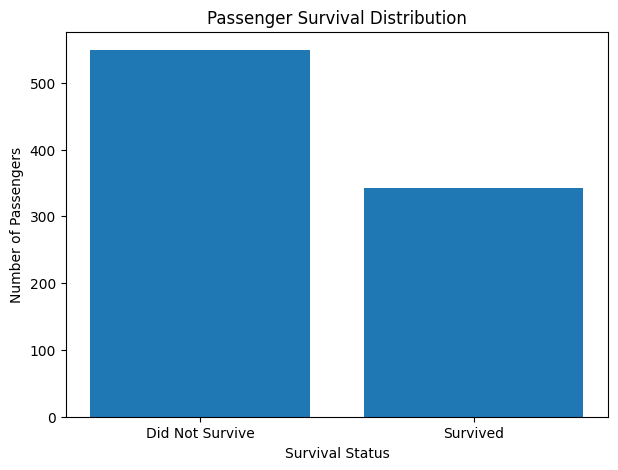

In [ ]:
# Visualization 1: Passenger Survival Distribution

survival_counts = cleaned_df["Survived"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(["Did Not Survive", "Survived"], survival_counts.values)

plt.title("Passenger Survival Distribution")
plt.xlabel("Survival Status")
plt.ylabel("Number of Passengers")

plt.show()

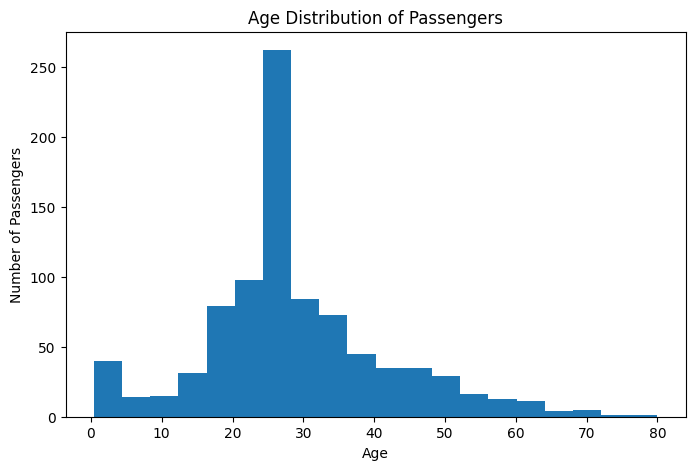

In [ ]:
# Visualization 2: Age Distribution

plt.figure(figsize=(8, 5))

plt.hist(cleaned_df["Age"], bins=20)

plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

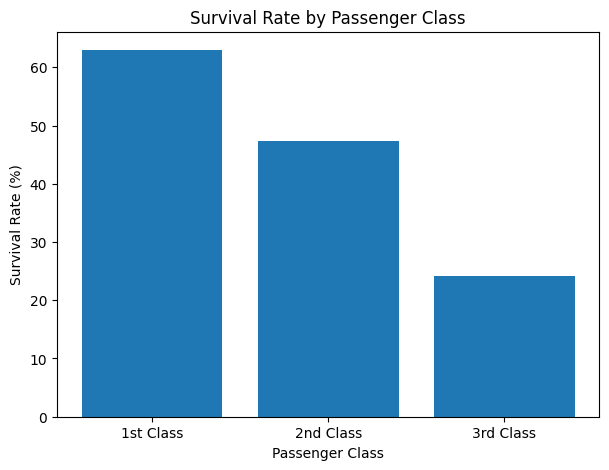

In [ ]:
# Visualization 3: Survival Rate by Passenger Class

survival_by_class = cleaned_df.groupby("Pclass")["Survived"].mean() * 100

plt.figure(figsize=(7, 5))
plt.bar(["1st Class", "2nd Class", "3rd Class"], survival_by_class.values)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")

plt.show()

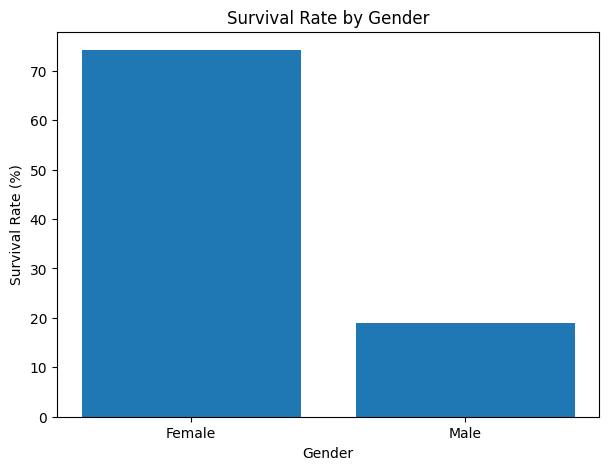

In [ ]:
# Visualization 4: Survival Rate by Gender

survival_by_gender = cleaned_df.groupby("Sex")["Survived"].mean() * 100

plt.figure(figsize=(7, 5))
plt.bar(["Female", "Male"], survival_by_gender.values)

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate (%)")

plt.show()

In [ ]:
# Step 16A: Correlation Analysis

numeric_df = cleaned_df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

print("Correlation Matrix:")
display(correlation.round(2))

Correlation Matrix:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.00,-0.01,-0.04,0.03,-0.06,-0.00,0.01
Survived,-0.01,1.00,-0.34,-0.06,-0.04,0.08,0.26
Pclass,-0.04,-0.34,1.00,-0.34,0.08,0.02,-0.55
Age,0.03,-0.06,-0.34,1.00,-0.23,-0.17,0.10
SibSp,-0.06,-0.04,0.08,-0.23,1.00,0.41,0.16
Parch,-0.00,0.08,0.02,-0.17,0.41,1.00,0.22
Fare,0.01,0.26,-0.55,0.10,0.16,0.22,1.00


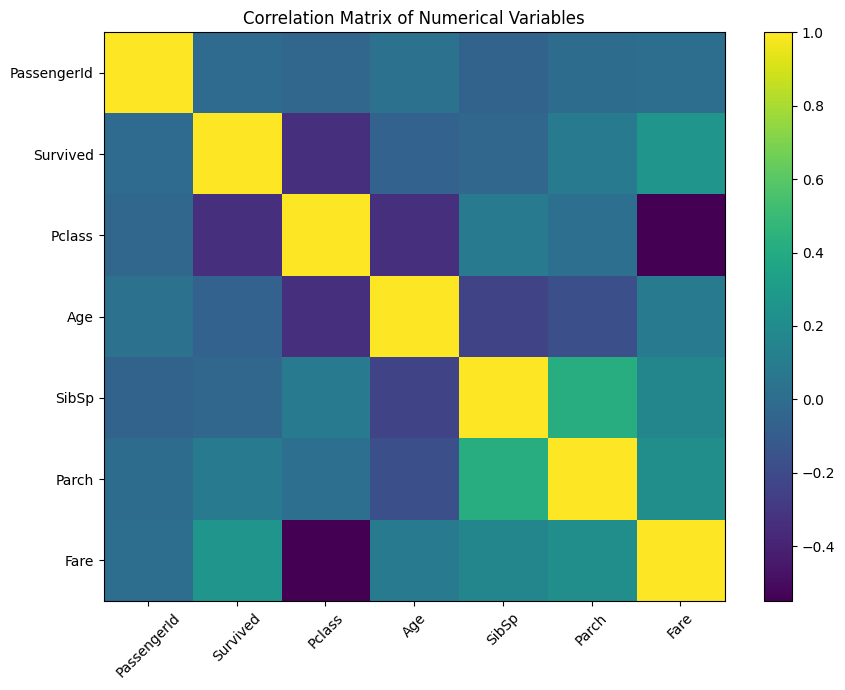

In [ ]:
# Step 16B: Correlation Matrix Visualization

plt.figure(figsize=(9, 7))

plt.imshow(correlation, aspect="auto")
plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Matrix of Numerical Variables")

plt.tight_layout()
plt.show()

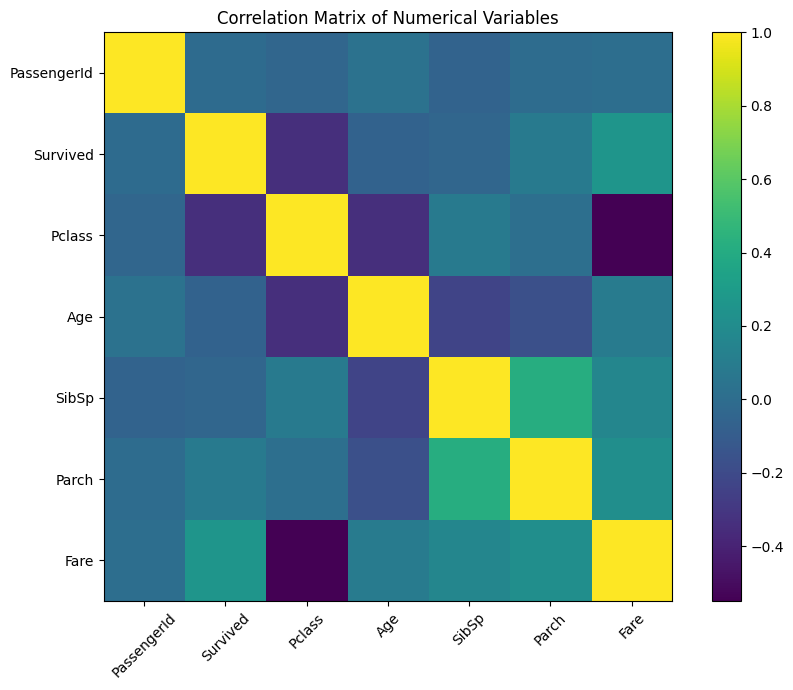

In [24]:
# Visualization 5: Correlation Matrix

correlation = cleaned_df.corr(numeric_only=True)

plt.figure(figsize=(9, 7))

plt.imshow(correlation)

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix of Numerical Variables")

plt.tight_layout()

plt.show()

In [ ]:
# Step 17: Generate key analytical insights

total_passengers = len(cleaned_df)

survived_count = cleaned_df["Survived"].sum()
survival_rate = cleaned_df["Survived"].mean() * 100

class_survival = cleaned_df.groupby("Pclass")["Survived"].mean() * 100
gender_survival = cleaned_df.groupby("Sex")["Survived"].mean() * 100

average_age = cleaned_df["Age"].mean()
average_fare = cleaned_df["Fare"].mean()

print("KEY INSIGHTS")
print("-" * 40)

print(f"Total passengers analysed: {total_passengers}")
print(f"Passengers survived: {survived_count}")
print(f"Overall survival rate: {survival_rate:.2f}%")
print(f"Average passenger age: {average_age:.2f} years")
print(f"Average fare: {average_fare:.2f}")

print("\nSurvival rate by passenger class:")
print(class_survival.round(2))

print("\nSurvival rate by gender:")
print(gender_survival.round(2))

KEY INSIGHTS
----------------------------------------
Total passengers analysed: 891
Passengers survived: 342
Overall survival rate: 38.38%
Average passenger age: 29.36 years
Average fare: 32.20

Survival rate by passenger class:
Pclass
1    62.96
2    47.28
3    24.24
Name: Survived, dtype: float64

Survival rate by gender:
Sex
female    74.20
male      18.89
Name: Survived, dtype: float64


In [ ]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape:
(891, 12)

Column Names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# Step 18: Save the cleaned dataset

cleaned_df.to_csv("cleaned_titanic_dataset.csv", index=False)

print("Cleaned Titanic dataset saved successfully.")